In [1]:
%matplotlib widget

from pathlib import Path
import json

import h5py
import numpy as np
import matplotlib.pyplot as plt

DPI = plt.rcParams['figure.dpi']

---

### TODO:
1. Load data: quaternions, timestamps, markup, repeats, participant info, coefs for sync, emg events
2. Create new timestamps for emg data
3. Interpolate markup and repeats data using emg timestamps and events
4. Transform quaternions timestamps using coefs
5. Check all gainted data using lineplot
6. Save data into hdf5 file

In [2]:
raw_data_dir = Path('/home/matthew/datasets/EMG_glove/')
synced_data_dir = raw_data_dir / 'synced'
synced_data_dir.mkdir(exist_ok=True, parents=True)

tmp_data_dir = Path('./tmp/data')

participant_number = 23
participant_folder = tmp_data_dir / str(participant_number)

In [3]:
with open(participant_folder / 'glove_to_emg_coefs.json', mode='r') as json_file:
    coefs = json.load(json_file)


with open(participant_folder / 'emg_events.json', mode='r') as json_file:
    emg_events = np.asarray(json.load(json_file)['points'], dtype=np.float32).reshape(-1, 2)
    if len(emg_events) != 106:
        print(f'EMG events length: {len(emg_events)}')


with h5py.File(raw_data_dir / f'{participant_number}.hdf5', mode='r') as hdf_file:
    record_date = hdf_file.attrs.get('date')
    participant_age = hdf_file.attrs.get('participant_age')
    
    participant_code = hdf_file.attrs.get('participant_code')
    if participant_code != participant_number:
        print(f'Number: {participant_number}')
        print(f'Code: {participant_code}')
        participant_code = participant_number
    
    participant_gender = hdf_file.attrs.get('participant_gender')
    participant_leading_hand = 'r'

    glove_group = hdf_file.get('position')
    bones_quaternions = glove_group.get('bones')[:]
    fingers_quaternions = glove_group.get('fingers')[:]
    
    lia_data = glove_group.get('lia')[:]
    acc_data = np.median((lia_data ** 2).sum(axis=-1), axis=-1)
    
    glove_ts = glove_group.get('timestamps')[:]
    glove_ts = (glove_ts - glove_ts[0]) / 1_000

with h5py.File(participant_folder / f'{participant_number}.hdf5', mode='r') as hdf_file:
    emg_data = hdf_file.get('emg')[:]
    markup_data = hdf_file.get('markup')[:]
    repeats_data = hdf_file.get('repeats')[:]

sampling_rate = 1024

emg_ts = np.arange(0, len(emg_data) / sampling_rate, 1 / sampling_rate)

In [4]:
ts_idx = 0

markup_arr = np.zeros_like(emg_ts, dtype=np.int8)
repeats_arr = np.zeros_like(emg_ts, dtype=np.int8)

for (start, end), gesture, repeat in zip(emg_events, markup_data, repeats_data):
    start_idx = np.where(emg_ts == start)[0].item()
    end_idx = np.where(emg_ts == end)[0].item()

    markup_arr[start_idx: end_idx + 1] = gesture
    repeats_arr[start_idx: end_idx + 1] = repeat

In [5]:
glove_ts = glove_ts * coefs['coef'] + coefs['intercept']

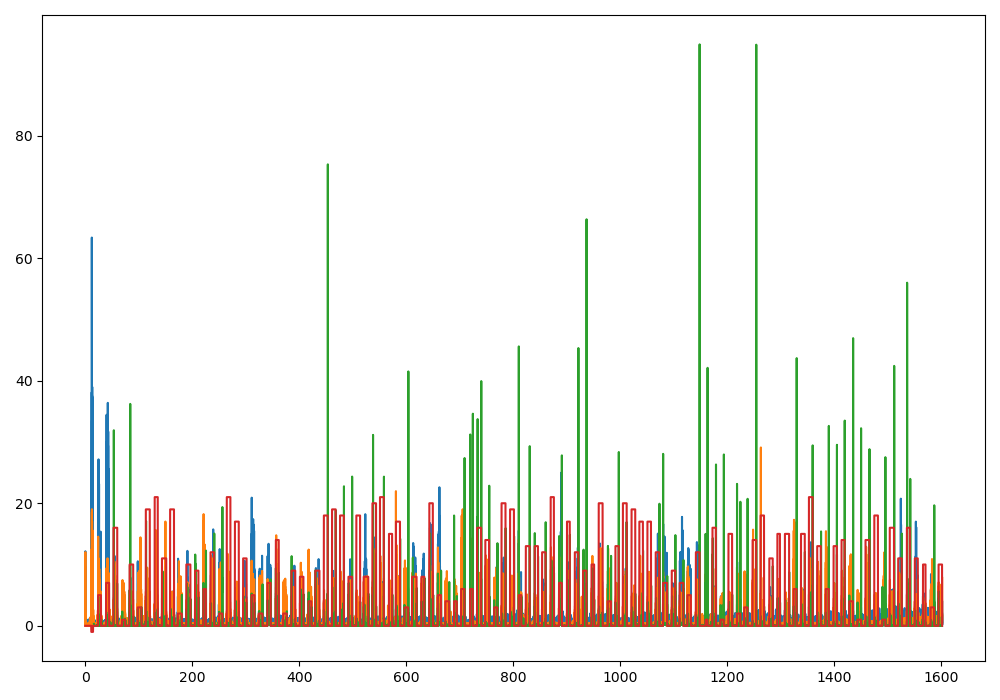

In [6]:
emg_array_1 = np.median(np.abs(emg_data[:, :64]), axis=-1)
emg_array_2 = np.median(np.abs(emg_data[:, 64:]), axis=-1)

plt.close()

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(w=1000 / DPI, h=700 / DPI)

# EMG plot
ax.plot(
    emg_ts,
    emg_array_1 / emg_array_1.std()
)
ax.plot(
    emg_ts,
    emg_array_2 / emg_array_2.std()
)

# Lia plot
ax.plot(
    glove_ts,
    acc_data / acc_data.std()
)

# Gesture plot
ax.plot(
    emg_ts,
    markup_arr
)

fig.tight_layout()
plt.show()

In [7]:
with h5py.File(synced_data_dir / f'{participant_code}.hdf5', mode='w') as hdf_file:
    hdf_file.attrs['record_date'] = record_date
    hdf_file.attrs['participant_age'] = participant_age
    hdf_file.attrs['participant_code'] = participant_code
    hdf_file.attrs['participant_gender'] = participant_gender
    hdf_file.attrs['participant_leading_hand'] = participant_leading_hand

    emg_group = hdf_file.create_group('emg_group')
    emg_group.attrs['sampling_rate'] = 1024
    emg_group.create_dataset('emg', data=emg_data)
    emg_group.create_dataset('ts', data=emg_ts)
    emg_group.create_dataset('gestures', data=markup_arr)
    emg_group.create_dataset('repeats', data=repeats_arr)

    glove_group = hdf_file.create_group('glove_group')
    glove_group.create_dataset('lia', data=lia_data)
    glove_group.create_dataset('bones_quaternions', data=bones_quaternions)
    glove_group.create_dataset('fingers_quaternions', data=fingers_quaternions)
    glove_group.create_dataset('ts', data=glove_ts)